In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from statsmodels.nonparametric.smoothers_lowess import lowess

In [2]:
# Step 1: Generate noisy time series

np.random.seed(42)

n_points = 200

t = np.linspace(
    0,
    4 * np.pi,
    n_points
)

true_signal = (
    np.sin(t) +
    0.3 * np.sin(3 * t)
)

noise = np.random.normal(
    0,
    0.3,
    n_points
)

observed = true_signal + noise

df = pd.DataFrame({
    't': t,
    'true_signal': true_signal,
    'observed': observed
})

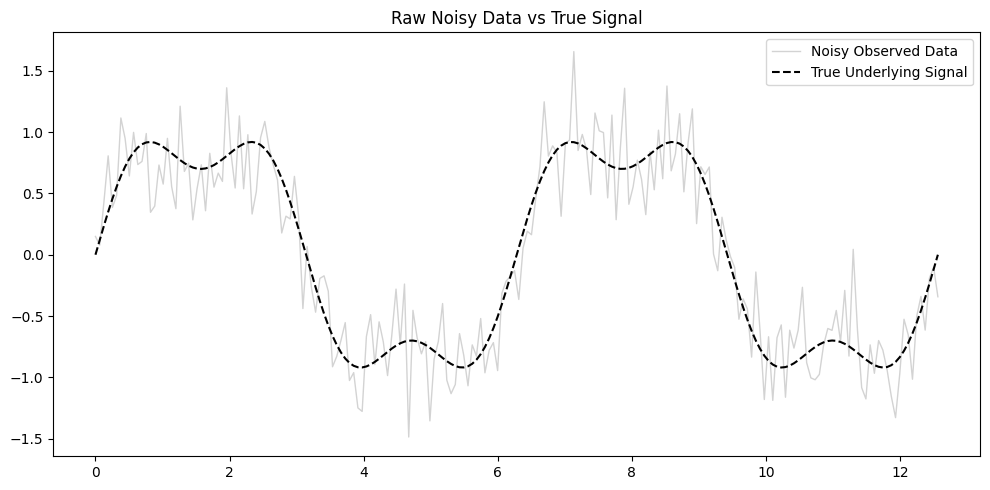

In [3]:
# Step 2: Plot raw data

plt.figure(figsize=(10, 5))

plt.plot(
    df['t'],
    df['observed'],
    label='Noisy Observed Data',
    color='lightgray',
    linewidth=1
)

plt.plot(
    df['t'],
    df['true_signal'],
    label='True Underlying Signal',
    color='black',
    linestyle='--'
)

plt.title(
    'Raw Noisy Data vs True Signal'
)

plt.legend()
plt.tight_layout()
plt.show()

In [4]:
# Step 4: Exponential Weighted Moving Average

df['ewma'] = (
    df['observed']
    .ewm(alpha=0.15)
    .mean()
)

In [5]:
# Step 5: Savitzky-Golay filter

df['savgol'] = savgol_filter(
    df['observed'],
    window_length=15,
    polyorder=3
)

In [6]:
# Step 6: LOESS / LOWESS

loess_result = lowess(
    df['observed'],
    df['t'],
    frac=0.1
)

df['loess'] = loess_result[:, 1]

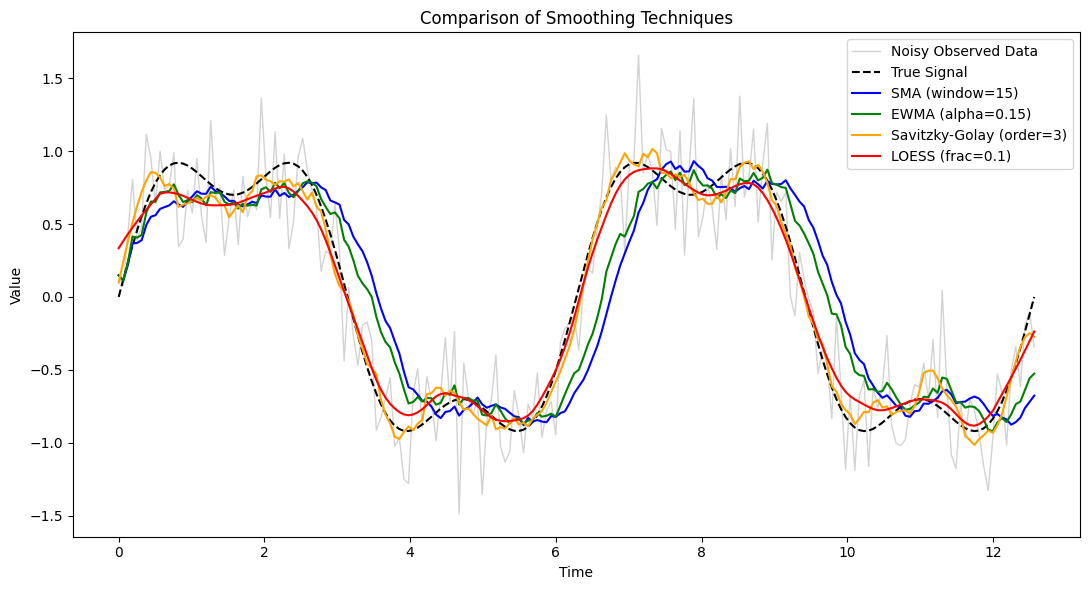

In [8]:
# Step 7: Compare all techniques

# Define SMA window and calculate SMA as it was missing
window = 15
df['sma'] = df['observed'].rolling(window=window, min_periods=1).mean()

plt.figure(figsize=(11, 6))

plt.plot(
    df['t'],
    df['observed'],
    color='lightgray',
    label='Noisy Observed Data',
    linewidth=1
)

plt.plot(
    df['t'],
    df['true_signal'],
    color='black',
    linestyle='--',
    label='True Signal'
)

plt.plot(
    df['t'],
    df['sma'],
    color='blue',
    label=f'SMA (window={window})'
)

plt.plot(
    df['t'],
    df['ewma'],
    color='green',
    label='EWMA (alpha=0.15)'
)

plt.plot(
    df['t'],
    df['savgol'],
    color='orange',
    label='Savitzky-Golay (order=3)'
)

plt.plot(
    df['t'],
    df['loess'],
    color='red',
    label='LOESS (frac=0.1)'
)

plt.title(
    'Comparison of Smoothing Techniques'
)

plt.xlabel('Time')
plt.ylabel('Value')

plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# Step 8: RMSE calculation

def rmse(a, b):

    mask = (
        ~np.isnan(a) &
        ~np.isnan(b)
    )

    return np.sqrt(
        np.mean(
            (a[mask] - b[mask]) ** 2
        )
    )

results = {
    'Raw (no smoothing)': rmse(
        df['observed'].values,
        df['true_signal'].values
    ),

    'SMA': rmse(
        df['sma'].values,
        df['true_signal'].values
    ),

    'EWMA': rmse(
        df['ewma'].values,
        df['true_signal'].values
    ),

    'Savitzky-Golay': rmse(
        df['savgol'].values,
        df['true_signal'].values
    ),

    'LOESS': rmse(
        df['loess'].values,
        df['true_signal'].values
    )
}

for method, error in results.items():

    print(
        f'{method:20s} RMSE = {error:.4f}'
    )

Raw (no smoothing)   RMSE = 0.2789
SMA                  RMSE = 0.3504
EWMA                 RMSE = 0.2661
Savitzky-Golay       RMSE = 0.1009
LOESS                RMSE = 0.1093
